## Instalación de dependencias

In [1]:
%pip install ucimlrepo pandas matplotlib seaborn --quiet

Note: you may need to restart the kernel to use updated packages.


# Sección 1 — Carga del dataset

*Después de completar esta celda → primer commit de código*

In [2]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import os

# Descargar el dataset Heart Disease de UCI (Cleveland, id=45)
dataset = fetch_ucirepo(id=45)

# Extraer features y variable objetivo
X = dataset.data.features
y = dataset.data.targets

# Unir en un solo DataFrame
df = pd.concat([X, y], axis=1)

# Renombrar la columna objetivo
df.rename(columns={"num": "enfermedad"}, inplace=True)

# Convertir a variable binaria: 0 = sano, 1 = enfermo
df["enfermedad"] = (df["enfermedad"] > 0).astype(int)

# Guardar para no descargar en cada ejecución
os.makedirs("data", exist_ok=True)
df.to_csv("data/heart.csv", index=False)

print("Dataset descargado correctamente.")
print(f"Forma: {df.shape}")
print(f"Columnas: {list(df.columns)}")

Dataset descargado correctamente.
Forma: (303, 14)
Columnas: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'enfermedad']


# Sección 2 — Inspección inicial

*Después de completar esta celda → segundo commit de código*

In [3]:
df = pd.read_csv("data/heart.csv")

print("--- Primeras 5 filas ---")
print(df.head())

--- Primeras 5 filas ---
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   1       145   233    1        2      150      0      2.3      3   
1   67    1   4       160   286    0        2      108      1      1.5      2   
2   67    1   4       120   229    0        2      129      1      2.6      2   
3   37    1   3       130   250    0        0      187      0      3.5      3   
4   41    0   2       130   204    0        2      172      0      1.4      1   

    ca  thal  enfermedad  
0  0.0   6.0           0  
1  3.0   3.0           1  
2  2.0   7.0           1  
3  0.0   3.0           0  
4  0.0   3.0           0  


In [4]:
print("--- Tipos de datos ---")
print(df.dtypes)

--- Tipos de datos ---
age             int64
sex             int64
cp              int64
trestbps        int64
chol            int64
fbs             int64
restecg         int64
thalach         int64
exang           int64
oldpeak       float64
slope           int64
ca            float64
thal          float64
enfermedad      int64
dtype: object


In [5]:
print("--- Estadísticas descriptivas ---")
df.describe()

--- Estadísticas descriptivas ---


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,enfermedad
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,0.499120
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


In [6]:
print("--- Valores nulos por columna ---")
print(df.isnull().sum())

print("\n--- Distribución de la variable objetivo ---")
conteo = df["enfermedad"].value_counts()
print(conteo)
print(f"\nProporción de enfermos: {conteo[1] / len(df):.2%}")

--- Valores nulos por columna ---
age           0
sex           0
cp            0
trestbps      0
chol          0
fbs           0
restecg       0
thalach       0
exang         0
oldpeak       0
slope         0
ca            4
thal          2
enfermedad    0
dtype: int64

--- Distribución de la variable objetivo ---
enfermedad
0    164
1    139
Name: count, dtype: int64

Proporción de enfermos: 45.87%


In [7]:
print("--- Columnas con pocos valores únicos (posibles categóricas) ---")
for col in df.columns:
    if df[col].nunique() <= 6:
        print(f"  {col}: {sorted(df[col].unique())}")

--- Columnas con pocos valores únicos (posibles categóricas) ---
  sex: [np.int64(0), np.int64(1)]
  cp: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
  fbs: [np.int64(0), np.int64(1)]
  restecg: [np.int64(0), np.int64(1), np.int64(2)]
  exang: [np.int64(0), np.int64(1)]
  slope: [np.int64(1), np.int64(2), np.int64(3)]
  ca: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(nan)]
  thal: [np.float64(3.0), np.float64(6.0), np.float64(7.0), np.float64(nan)]
  enfermedad: [np.int64(0), np.int64(1)]


# Sección 3 — Limpieza de datos

*Después de completar esta celda → tercer commit de código*

In [8]:
df = pd.read_csv("data/heart.csv")

print(f"Filas antes de limpieza: {len(df)}")

# Verificar y eliminar duplicados
n_dup = df.duplicated().sum()
print(f"Duplicados encontrados: {n_dup}")
if n_dup > 0:
    df.drop_duplicates(inplace=True)

Filas antes de limpieza: 303
Duplicados encontrados: 0


In [9]:
# Verificar rangos inválidos
print("Registros con edad fuera de rango (20-80):",
      len(df[(df["age"] < 20) | (df["age"] > 80)]))

print("Registros con presión arterial = 0:",
      len(df[df["trestbps"] == 0]))

print("Registros con colesterol = 0:",
      len(df[df["chol"] == 0]))

Registros con edad fuera de rango (20-80): 0
Registros con presión arterial = 0: 0
Registros con colesterol = 0: 0


In [11]:
# Reemplazar ceros inválidos con la mediana de la columna
for col in ["trestbps", "chol"]:
    n_ceros = (df[col] == 0).sum()
    if n_ceros > 0:
        mediana = df[df[col] != 0][col].median()
        df[col] = df[col].replace(0, mediana)
        print(f"  '{col}': {n_ceros} ceros → mediana={mediana}")
    else:
        print(f"  '{col}': sin ceros inválidos.")

# Guardar dataset limpio
df.to_csv("data/heart_limpio.csv", index=False)
print(f"\nDataset limpio guardado. Filas finales: {len(df)}")

  'trestbps': sin ceros inválidos.
  'chol': sin ceros inválidos.

Dataset limpio guardado. Filas finales: 303


# Sección 4 — Análisis exploratorio (EDA)

*Después de completar esta celda → cuarto commit de código*

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("outputs", exist_ok=True)
df = pd.read_csv("data/heart_limpio.csv")

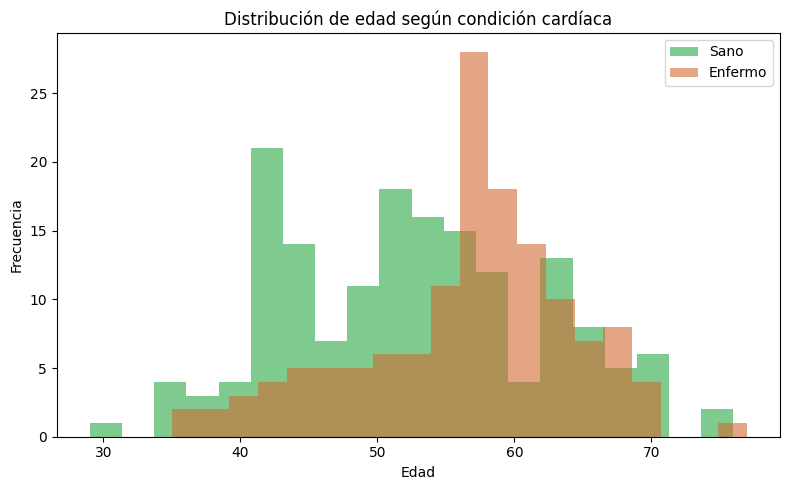

Guardada: outputs/dist_edad.png


In [13]:
# Figura 1 — Distribución de edad por condición
fig, ax = plt.subplots(figsize=(8, 5))
for cond, label, color in [(0, "Sano", "#28a745"), (1, "Enfermo", "#d16a30")]:
    df[df["enfermedad"] == cond]["age"].plot(
        kind="hist", bins=20, alpha=0.6, ax=ax,
        label=label, color=color
    )
ax.set_title("Distribución de edad según condición cardíaca")
ax.set_xlabel("Edad")
ax.set_ylabel("Frecuencia")
ax.legend()
plt.tight_layout()
plt.savefig("outputs/dist_edad.png", dpi=100)
plt.show()
print("Guardada: outputs/dist_edad.png")

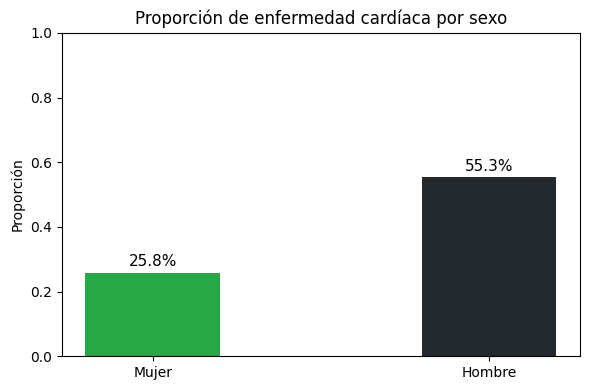

Guardada: outputs/proporcion_sexo.png


In [14]:
# Figura 2 — Proporción de enfermos por sexo
tabla = df.groupby("sex")["enfermedad"].mean().reset_index()
tabla["sex"] = tabla["sex"].map({0: "Mujer", 1: "Hombre"})

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(tabla["sex"], tabla["enfermedad"],
       color=["#28a745", "#24292e"], width=0.4)
ax.set_title("Proporción de enfermedad cardíaca por sexo")
ax.set_ylabel("Proporción")
ax.set_ylim(0, 1)
for i, v in enumerate(tabla["enfermedad"]):
    ax.text(i, v + 0.02, f"{v:.1%}", ha="center", fontsize=11)
plt.tight_layout()
plt.savefig("outputs/proporcion_sexo.png", dpi=100)
plt.show()
print("Guardada: outputs/proporcion_sexo.png")

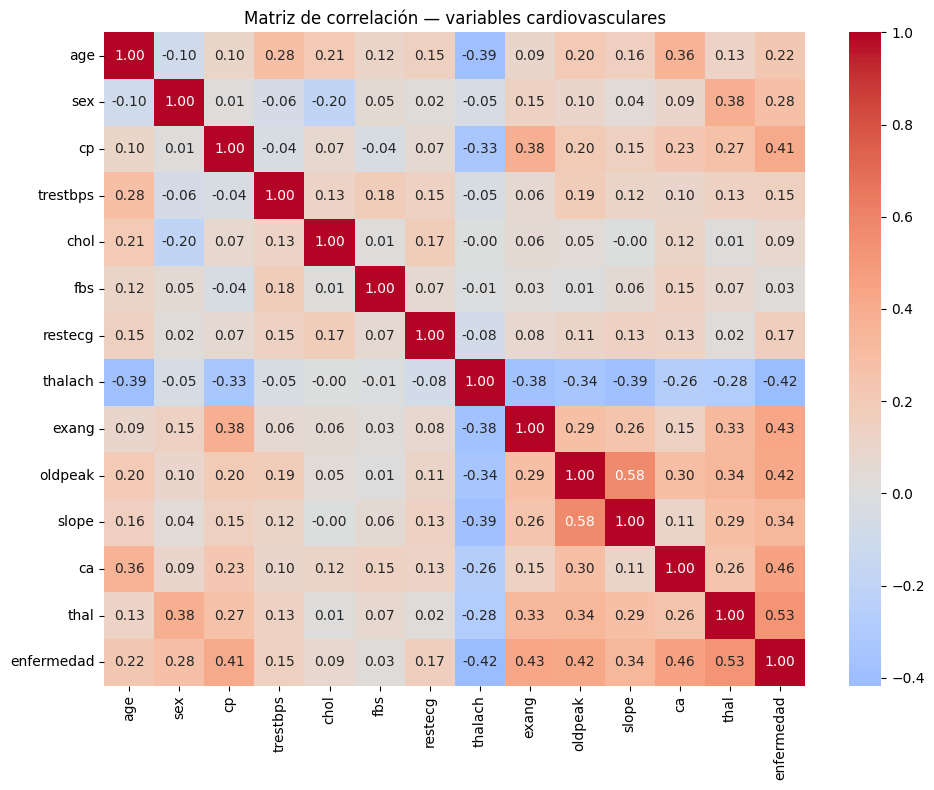

Guardada: outputs/correlacion.png


In [15]:
# Figura 3 — Matriz de correlación
fig, ax = plt.subplots(figsize=(10, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, ax=ax)
ax.set_title("Matriz de correlación — variables cardiovasculares")
plt.tight_layout()
plt.savefig("outputs/correlacion.png", dpi=100)
plt.show()
print("Guardada: outputs/correlacion.png")

In [16]:
# Tabla resumen por condición
resumen = df.groupby("enfermedad")[["age","trestbps","chol","thalach"]].mean()
resumen.index = resumen.index.map({0: "Sano", 1: "Enfermo"})
print("--- Estadísticas medias por condición ---")
resumen.round(2)

--- Estadísticas medias por condición ---


,age,trestbps,chol,thalach
enfermedad,,,,
Sano,52.59,129.25,242.64,158.38
Enfermo,56.63,134.57,251.47,139.26


# FASE 2 — Corrección del historial
Esta celda representa el cambio que vas a commitear con un mensaje malo a propósito
y luego corregir usando git reset. Lee las instrucciones de la guía antes de ejecutar.

In [17]:
# Agrega al final del README.md el resultado clave del EDA.
# Este cambio es el que vas a commitear mal y luego corregir.

prop_enfermos = df["enfermedad"].mean()

linea = (
    f"\n## Resultado clave\n"
    f"El {prop_enfermos:.1%} de los pacientes del dataset "
    f"presenta enfermedad cardíaca.\n"
)

with open("README.md", "a", encoding="utf-8") as f:
    f.write(linea)

print("README.md actualizado con el resultado del EDA.")
print(linea)

README.md actualizado con el resultado del EDA.

## Resultado clave
El 45.9% de los pacientes del dataset presenta enfermedad cardíaca.



# FASE 3 — Rama feature/estadisticas
Vuelve a main con git checkout main, luego crea la rama con
git checkout -b feature/estadisticas antes de ejecutar esta celda.

In [18]:
df = pd.read_csv("data/heart_limpio.csv")

# Crear grupos de edad
bins   = [20, 40, 55, 70, 90]
labels = ["20-40", "41-55", "56-70", "71+"]
df["grupo_edad"] = pd.cut(df["age"], bins=bins,
                           labels=labels, right=True)

print("=" * 55)
print("RESUMEN ESTADÍSTICO POR GRUPO DE EDAD")
print("=" * 55)

RESUMEN ESTADÍSTICO POR GRUPO DE EDAD


In [19]:
# Proporción de enfermos por grupo de edad
print("--- Proporción de enfermedad por grupo ---")
prop = df.groupby("grupo_edad", observed=True)["enfermedad"].mean()
for grupo, valor in prop.items():
    barra = "█" * int(valor * 20)
    print(f"  {grupo:6s}: {valor:.2%}  {barra}")

--- Proporción de enfermedad por grupo ---
  20-40 : 33.33%  ██████
  41-55 : 32.33%  ██████
  56-70 : 60.96%  ████████████
  71+   : 16.67%  ███


In [20]:
# Estadísticas de presión y colesterol por grupo
print("--- Presión arterial media por grupo ---")
print(df.groupby("grupo_edad", observed=True)["trestbps"].mean().round(1))

print("\n--- Colesterol medio por grupo ---")
print(df.groupby("grupo_edad", observed=True)["chol"].mean().round(1))

--- Presión arterial media por grupo ---
grupo_edad
20-40    126.2
41-55    127.0
56-70    136.8
71+      127.8
Name: trestbps, dtype: float64

--- Colesterol medio por grupo ---
grupo_edad
20-40    215.0
41-55    242.2
56-70    254.6
71+      247.7
Name: chol, dtype: float64


In [21]:
# Guardar resumen completo
resumen = df.groupby("grupo_edad", observed=True).agg(
    n_registros      = ("age",        "count"),
    edad_media       = ("age",        "mean"),
    prop_enfermos    = ("enfermedad", "mean"),
    presion_media    = ("trestbps",   "mean"),
    colesterol_medio = ("chol",       "mean")
).round(2)

resumen.to_csv("outputs/resumen_por_grupo.csv")
print("Guardado: outputs/resumen_por_grupo.csv")
resumen

Guardado: outputs/resumen_por_grupo.csv


,n_registros,edad_media,prop_enfermos,presion_media,colesterol_medio
grupo_edad,,,,,
20-40,18,36.83,0.33,126.22,215.00
41-55,133,48.41,0.32,126.99,242.24
56-70,146,61.33,0.61,136.80,254.62
71+,6,73.33,0.17,127.83,247.67
